## Imports

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import spacy
from collections import Counter
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re

## Import Data

--- Basic Info ---
<class 'pandas.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   is_sarcastic  28619 non-null  int64
 1   headline      28619 non-null  str  
 2   article_link  28619 non-null  str  
dtypes: int64(1), str(2)
memory usage: 670.9 KB
None


--- Missing Values ---
is_sarcastic    0
headline        0
article_link    0
dtype: int64


--- Duplicate Headlines ---
Total duplicate headlines: 116
Dataset size after dropping duplicates: 28503


--- Class Distribution ---
is_sarcastic
0    14951
1    13552
Name: count, dtype: int64
Sarcastic: 47.55%
Non-Sarcastic: 52.45%


/var/folders/x1/8j642crj3yv1k67btv8nvh_h0000gn/T/ipykernel_6301/620173857.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_sarcastic', palette='Set2')


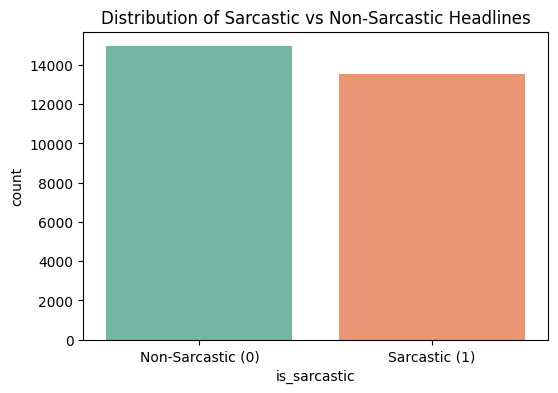

--- Word Count Statistics ---
                count       mean       std  min  25%   50%   75%    max
is_sarcastic                                                           
0             14951.0   9.824360  2.879530  2.0  8.0  10.0  12.0   38.0
1             13552.0  10.321798  3.850536  2.0  8.0  10.0  13.0  151.0


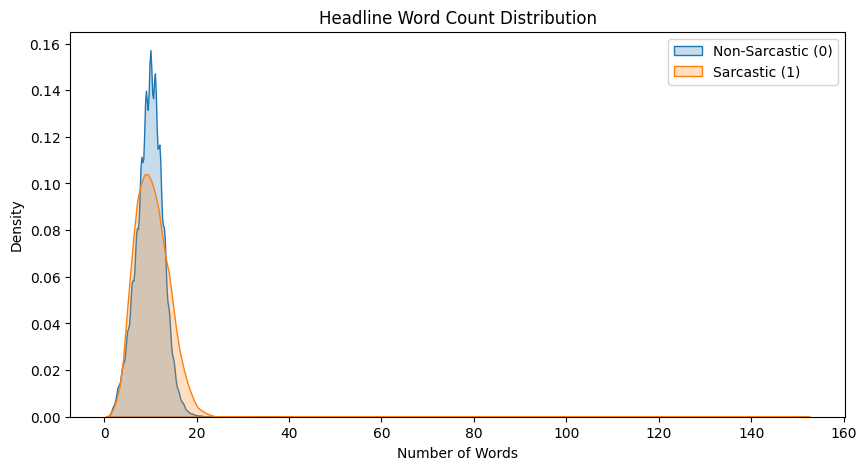

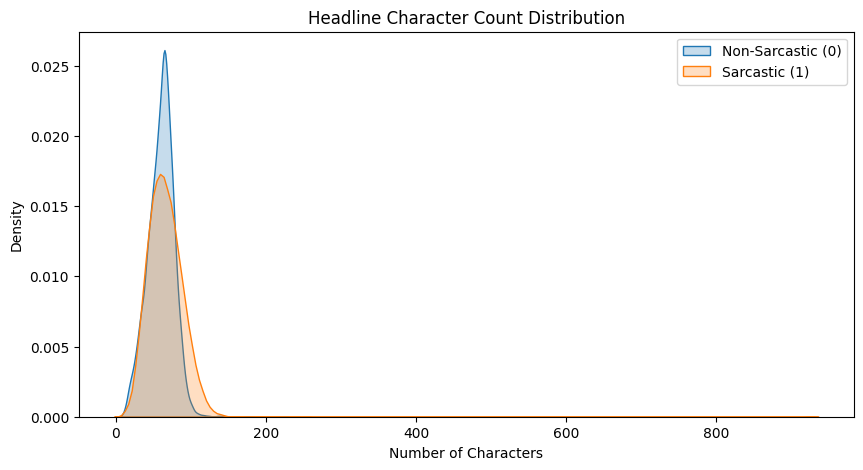

In [ ]:
# 1. Load the data
df = pd.read_json('Sarcasm_Headlines_Dataset_v2.json', lines=True)

print("--- Basic Info ---")
print(df.info())
print("\n")

# 2. Check for Missing Values & Duplicates
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n")

print("--- Duplicate Headlines ---")
duplicates = df.duplicated(subset=['headline']).sum()
print(f"Total duplicate headlines: {duplicates}")
if duplicates > 0:
    # Drop duplicates to keep the model from memorizing repeated text
    df = df.drop_duplicates(subset=['headline'])
    print(f"Dataset size after dropping duplicates: {len(df)}")
print("\n")

# 3. Class Balance Analysis
print("--- Class Distribution ---")
class_counts = df['is_sarcastic'].value_counts()
print(class_counts)
print(f"Sarcastic: {class_counts[1] / len(df) * 100:.2f}%")
print(f"Non-Sarcastic: {class_counts[0] / len(df) * 100:.2f}%")

# Plot Class Balance
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_sarcastic', palette='Set2')
plt.title("Distribution of Sarcastic vs Non-Sarcastic Headlines")
plt.xticks([0, 1],['Non-Sarcastic (0)', 'Sarcastic (1)'])
plt.show()

# 4. Text Length Analysis (Word Count & Character Count)
# Create new columns for analysis
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

# Display Summary Statistics for lengths grouped by class
print("--- Word Count Statistics ---")
print(df.groupby('is_sarcastic')['word_count'].describe())

# Plot Word Count Distribution
plt.figure(figsize=(10,5))
sns.kdeplot(data=df[df['is_sarcastic'] == 0], x='word_count', label='Non-Sarcastic (0)', fill=True)
sns.kdeplot(data=df[df['is_sarcastic'] == 1], x='word_count', label='Sarcastic (1)', fill=True)
plt.title("Headline Word Count Distribution")
plt.xlabel("Number of Words")
plt.legend()
plt.show()

# Plot Character Count Distribution
plt.figure(figsize=(10,5))
sns.kdeplot(data=df[df['is_sarcastic'] == 0], x='char_count', label='Non-Sarcastic (0)', fill=True)
sns.kdeplot(data=df[df['is_sarcastic'] == 1], x='char_count', label='Sarcastic (1)', fill=True)
plt.title("Headline Character Count Distribution")
plt.xlabel("Number of Characters")
plt.legend()

In [3]:
long_non_sarcastic = df[(df['is_sarcastic'] == 0) & (df['word_count'] > 12)]
long_sarcastic = df[(df['is_sarcastic'] == 1) & (df['word_count'] > 13)]

print(f"--- NON-SARCASTIC HEADLINES > 12 WORDS (Total: {len(long_non_sarcastic)}) ---")
print("Top 5 Longest (The Outliers):")
# nlargest sorts by the word count so we see the biggest ones (like the 38-word max)
for headline in long_non_sarcastic.nlargest(5, 'word_count')['headline']:
    print(f"- {headline}")

print("\nRandom Sample of 3:")
for headline in long_non_sarcastic.sample(3)['headline']:
    print(f"- {headline}")


print(f"\n--- SARCASTIC HEADLINES > 13 WORDS (Total: {len(long_sarcastic)}) ---")
print("Top 5 Longest (The Outliers):")
# This will reveal what that massive 151-word sentence actually is!
for headline in long_sarcastic.nlargest(5, 'word_count')['headline']:
    print(f"- {headline}")

print("\nRandom Sample of 3:")
for headline in long_sarcastic.sample(3)['headline']:
    print(f"- {headline}")

--- NON-SARCASTIC HEADLINES > 12 WORDS (Total: 2431) ---
Top 5 Longest (The Outliers):
- occasionally you realize someone you thought was a dear friend is actually a foe, their true character finally revealed. but how do you forgive the unforgivable? here are my 10 steps to handling betrayal with elegance and grace.
- top 3 reasons why 400 ppm co2 is/is not the end of the world, or how i learned to stop worrying and love air conditioning. part 1: the numbers
- 'how do we treat the little people, joan?' i asked. and she said, 'why, we treat them better. we only s--t on people at our level or higher.'
- with big names like the cure and grimes shining at bestival toronto, it was the details and even a michigan-born techno artist that made it a wonderland
- something to vote for on november 8, 2016:          elect 279 candidates on election day and the united states leads the world in fighting climate change!

Random Sample of 3:
- why more older folks are turning to pot to fix what ails t

In [4]:
# 1. Isolate the short and long outliers
short_outliers = df[df['word_count'] < 3]
long_outliers = df[df['word_count'] > 25]

print(f"Total Short Outliers (< 3 words): {len(short_outliers)}")
print(f"Total Long Outliers (> 25 words): {len(long_outliers)}\n")

# ==========================================
# 2. VIEW THE SHORT OUTLIERS
# ==========================================
print("--- EXAMPLES OF SHORT OUTLIERS (< 3 words) ---")
# Using .head(10) to see the first 10 extremely short headlines
for headline in short_outliers['headline'].head(10):
    print(f"- {headline}")

print("\n")

# ==========================================
# 3. VIEW THE LONG OUTLIERS
# ==========================================
print("--- EXAMPLES OF LONG OUTLIERS (> 25 words) ---")
# Using .sample() to see a random mix of these run-on sentences
# We use min() just in case there are fewer than 5 long outliers
for headline in long_outliers['headline'].sample(min(5, len(long_outliers))):
    print(f"- {headline}")

print("\n")

# ==========================================
# 4. APPLY THE FILTER (THE CLEAN UP)
# ==========================================
# Now that we've seen them, we keep only the good data
df_clean = df[(df['word_count'] >= 3) & (df['word_count'] <= 25)]

print("--- CLEANING SUMMARY ---")
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)}")
print(f"Total rows removed: {len(df) - len(df_clean)}")

Total Short Outliers (< 3 words): 108
Total Long Outliers (> 25 words): 13

--- EXAMPLES OF SHORT OUTLIERS (< 3 words) ---
- trump's tailspin
- sunday roundup
- life unfair
- cher back
- clean machine
- tape dispensed
- willow rented
- december's people
- doritos good
- much ado...


--- EXAMPLES OF LONG OUTLIERS (> 25 words) ---
- jared kushner claims that russian interference less damaging to u.s. democracy than saudi arabia, nepotism, israel, cambridge analytica, uae, illicit donations, erik prince, bill barr, and financial entanglements
- maya angelou, poet, author, civil rights activist, and—holy cow—tony award–nominated actress, college professor, magazine editor, streetcar conductor—really? streetcar conductor? wow—calypso singer, nightclub performer, and foreign journalist, dead at 86
- report: doing your part to stop climate change now requires planting 30,000 new trees, getting 40,000 cars off the road, reviving 20 square miles of coral reef
- hot wheels ranked number one toy

/var/folders/x1/8j642crj3yv1k67btv8nvh_h0000gn/T/ipykernel_6301/1022243616.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=[val[1] for val in top_bigrams_real], y=[val[0] for val in top_bigrams_real], palette='Blues_r')
/var/folders/x1/8j642crj3yv1k67btv8nvh_h0000gn/T/ipykernel_6301/1022243616.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=[val[1] for val in top_bigrams_sarcastic], y=[val[0] for val in top_bigrams_sarcastic], palette='Oranges_r')


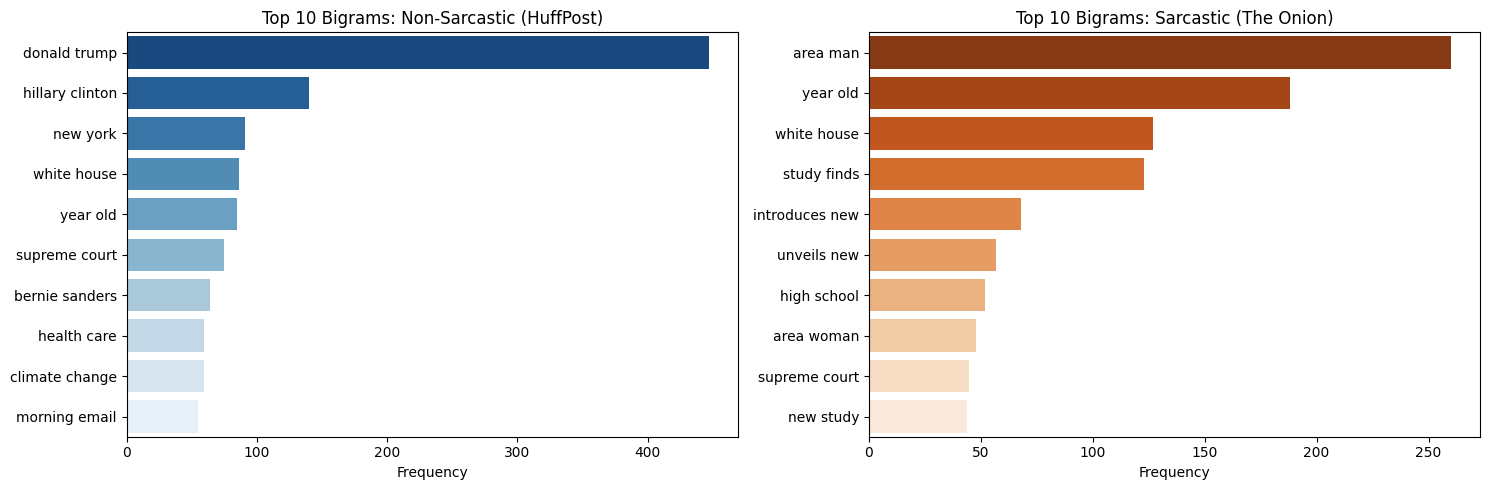

--- TOP 10 TRIGRAMS: NON-SARCASTIC ---
huffpost rise need (22)
rise need know (22)
friday morning email (15)
new york city (13)
lin manuel miranda (11)
friday talking points (11)
new york times (11)
thursday morning email (11)
donald trump says (11)
black lives matter (10)

--- TOP 10 TRIGRAMS: SARCASTIC ---
new study finds (35)
new york times (17)
new report finds (11)
unveils new line (9)
study finds humans (8)
report average american (8)
onion social ceo (8)
new evidence suggests (7)
introduces new line (7)
12 year old (7)


In [5]:
# Assuming your cleaned dataframe from the last step is named 'df_clean'

# 1. Helper function to get the top N-grams
def get_top_ngrams(corpus, n=10, ngram_range=(2, 2)):
    # Using scikit-learn's built-in english stop words
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq =[(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Separate the text by class
text_real = df_clean[df_clean['is_sarcastic'] == 0]['headline']
text_sarcastic = df_clean[df_clean['is_sarcastic'] == 1]['headline']

# ==========================================
# 2. BIGRAM ANALYSIS (2-Word Phrases)
# ==========================================
top_bigrams_real = get_top_ngrams(text_real, n=10, ngram_range=(2, 2))
top_bigrams_sarcastic = get_top_ngrams(text_sarcastic, n=10, ngram_range=(2, 2))

# Plotting Bigrams
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Real Bigrams
sns.barplot(ax=axes[0], x=[val[1] for val in top_bigrams_real], y=[val[0] for val in top_bigrams_real], palette='Blues_r')
axes[0].set_title('Top 10 Bigrams: Non-Sarcastic (HuffPost)')
axes[0].set_xlabel('Frequency')

# Sarcastic Bigrams
sns.barplot(ax=axes[1], x=[val[1] for val in top_bigrams_sarcastic], y=[val[0] for val in top_bigrams_sarcastic], palette='Oranges_r')
axes[1].set_title('Top 10 Bigrams: Sarcastic (The Onion)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

# ==========================================
# 3. TRIGRAM ANALYSIS (3-Word Phrases)
# ==========================================
top_trigrams_real = get_top_ngrams(text_real, n=10, ngram_range=(3, 3))
top_trigrams_sarcastic = get_top_ngrams(text_sarcastic, n=10, ngram_range=(3, 3))

print("--- TOP 10 TRIGRAMS: NON-SARCASTIC ---")
for word, freq in top_trigrams_real:
    print(f"{word} ({freq})")

print("\n--- TOP 10 TRIGRAMS: SARCASTIC ---")
for word, freq in top_trigrams_sarcastic:
    print(f"{word} ({freq})")

In [6]:
# Define the core boilerplate phrases we found
boilerplate_phrases =[
    "huffpost rise",          # Catches "huffpost rise need to know", etc.
    "morning email",          # Catches "friday morning email", "thursday morning email"
    "friday talking points",
    "onion social ceo",
    "the onion"
]

print("--- INSPECTING BOILERPLATE HEADLINES ---\n")

# Loop through each phrase to see how it appears in the wild
for phrase in boilerplate_phrases:
    # Find all rows where the headline contains the phrase (case-insensitive)
    matches = df_clean[df_clean['headline'].str.contains(phrase, case=False, na=False)]
    
    print(f"Phrase: '{phrase}' (Total found: {len(matches)})")
    
    if len(matches) > 0:
        print("Examples:")
        # Print up to 5 random examples to see the context
        for headline in matches['headline'].sample(min(5, len(matches))):
            print(f"  - {headline}")
    print("-" * 60)

--- INSPECTING BOILERPLATE HEADLINES ---

Phrase: 'huffpost rise' (Total found: 25)
Examples:
  - huffpost rise morning newsbrief, october 20
  - huffpost rise: what you need to know on april 22
  - huffpost rise: what you need to know on may 5
  - huffpost rise: what you need to know on march 11
  - huffpost rise: what you need to know on april 20
------------------------------------------------------------
Phrase: 'morning email' (Total found: 55)
Examples:
  - tuesday's morning email: what's next in the bombing investigation
  - wednesday's morning email: conservatives aren't loving the proposed gop obamacare reform
  - monday's morning email: the aftermath of the baton rouge shooting that left three officers dead
  - wednesday's morning email: latest missile launch from north korea appears to put entire continental u.s. in range
  - saturday's morning email: funnies edition
------------------------------------------------------------
Phrase: 'friday talking points' (Total found: 11

In [13]:
df_clean.to_csv("cleaned_dataset.csv", index=False)

In [7]:
print(f"Dataset size before final cleaning: {len(df_clean)}")

# 1. DROP useless roundups completely
# The ~ operator means "NOT" (keep rows that do NOT contain this phrase)
df_clean = df_clean[~df_clean['headline'].str.contains("huffpost rise", case=False, na=False)]

# 2. STRIP the prefixes (Regex explanation: ^ means start of string, .*? means any characters until the target)
# Strip everything up to and including "morning email: "
df_clean['headline'] = df_clean['headline'].str.replace(r"^.*?morning email:\s*", "", case=False, regex=True)
# Strip "friday talking points -- "
df_clean['headline'] = df_clean['headline'].str.replace(r"^friday talking points\s*--\s*", "", case=False, regex=True)

# 3. SUBSTITUTE self-referential jokes to preserve grammar
df_clean['headline'] = df_clean['headline'].str.replace(r"onion social ceo", "tech ceo", case=False, regex=True)
df_clean['headline'] = df_clean['headline'].str.replace(r"'the onion'", "'news outlet'", case=False, regex=True)
df_clean['headline'] = df_clean['headline'].str.replace(r"the onion", "news outlet", case=False, regex=True)

# Remove any extra whitespace created during replacements
df_clean['headline'] = df_clean['headline'].str.strip()

print(f"Dataset size after final cleaning: {len(df_clean)}")

# Let's peek at a few replaced Onion headlines to make sure the grammar survived
print("\n--- Checking the Substitutions ---")
check_mask = df_clean['headline'].str.contains("news outlet|tech ceo", case=False, na=False)
for headline in df_clean[check_mask]['headline'].sample(min(3, len(df_clean[check_mask]))):
    print(f"- {headline}")

Dataset size before final cleaning: 28382
Dataset size after final cleaning: 28357

--- Checking the Substitutions ---
- sean hannity: donald trump should deny press credentials to major news outlets
- priscilla chan leaves mark zuckerberg for tech ceo
- tech ceo rebukes 480,000 crimes at international criminal tribunal including illegal surveillance, insider trading, mass murder, indecent exposure


Loading spaCy model...


/Users/jeremiahau/Downloads/project_cs4248/.venv/lib/python3.11/site-packages/spacy/util.py:969: UserWarning: [W095] Model 'en_core_web_sm' (3.7.1) was trained with spaCy v3.7.2 and may not be 100% compatible with the current version (3.8.11). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Analyzing 14858 Non-Sarcastic headlines (takes ~10 seconds)...
Analyzing 13499 Sarcastic headlines (takes ~10 seconds)...


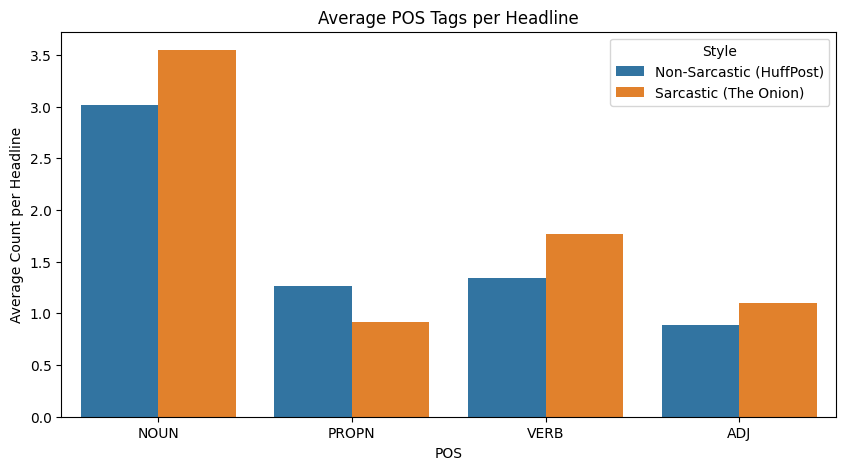

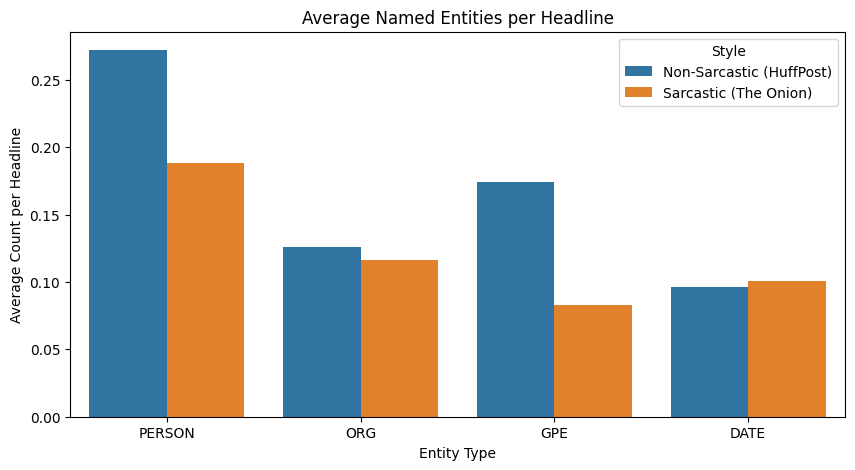

In [8]:
# 1. Load the spaCy English model
print("Loading spaCy model...")
nlp = spacy.load("en_core_web_sm")

# Assuming your cleaned dataframe is still named 'df_clean'
text_real = df_clean[df_clean['is_sarcastic'] == 0]['headline'].tolist()
text_sarcastic = df_clean[df_clean['is_sarcastic'] == 1]['headline'].tolist()

# 2. Helper function to process text quickly using nlp.pipe
def analyze_syntax(text_list):
    pos_counts = Counter()
    ner_counts = Counter()
    
    # nlp.pipe is highly optimized for processing large lists of text
    for doc in nlp.pipe(text_list, batch_size=500):
        # Count Part-of-Speech tags
        for token in doc:
            pos_counts[token.pos_] += 1
        # Count Named Entities
        for ent in doc.ents:
            ner_counts[ent.label_] += 1
            
    # Normalize counts (divide by number of headlines) to get the "average per headline"
    num_docs = len(text_list)
    pos_avg = {k: v / num_docs for k, v in pos_counts.items()}
    ner_avg = {k: v / num_docs for k, v in ner_counts.items()}
    
    return pos_avg, ner_avg

print(f"Analyzing {len(text_real)} Non-Sarcastic headlines (takes ~10 seconds)...")
pos_real, ner_real = analyze_syntax(text_real)

print(f"Analyzing {len(text_sarcastic)} Sarcastic headlines (takes ~10 seconds)...")
pos_sarcastic, ner_sarcastic = analyze_syntax(text_sarcastic)

# ==========================================
# 3. PLOT PART-OF-SPEECH (POS) COMPARISON
# ==========================================
# We focus on the big 4 that dictate style: Nouns, Proper Nouns, Verbs, Adjectives
key_pos = ['NOUN', 'PROPN', 'VERB', 'ADJ']

pos_data =[]
for pos in key_pos:
    pos_data.append({'POS': pos, 'Average Per Headline': pos_real.get(pos, 0), 'Style': 'Non-Sarcastic (HuffPost)'})
    pos_data.append({'POS': pos, 'Average Per Headline': pos_sarcastic.get(pos, 0), 'Style': 'Sarcastic (The Onion)'})

df_pos = pd.DataFrame(pos_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_pos, x='POS', y='Average Per Headline', hue='Style', palette=['#1f77b4', '#ff7f0e'])
plt.title('Average POS Tags per Headline')
plt.ylabel('Average Count per Headline')
plt.show()

# ==========================================
# 4. PLOT NAMED ENTITY (NER) COMPARISON
# ==========================================
# Key Entities: PERSON, ORG (Companies/Institutions), GPE (Geopolitical Entities/Locations), DATE
key_ner =['PERSON', 'ORG', 'GPE', 'DATE']

ner_data =[]
for ner in key_ner:
    ner_data.append({'Entity Type': ner, 'Average Per Headline': ner_real.get(ner, 0), 'Style': 'Non-Sarcastic (HuffPost)'})
    ner_data.append({'Entity Type': ner, 'Average Per Headline': ner_sarcastic.get(ner, 0), 'Style': 'Sarcastic (The Onion)'})

df_ner = pd.DataFrame(ner_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_ner, x='Entity Type', y='Average Per Headline', hue='Style', palette=['#1f77b4', '#ff7f0e'])
plt.title('Average Named Entities per Headline')
plt.ylabel('Average Count per Headline')
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jeremiahau/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Calculating sentiment scores...

--- Sentiment Score Summary ---
Non-Sarcastic (HuffPost):
count    14858.000000
mean        -0.012587
std          0.392988
min         -0.945100
25%         -0.296000
50%          0.000000
75%          0.250000
max          0.934800
Name: sentiment_score, dtype: float64

Sarcastic (The Onion):
count    13499.000000
mean        -0.017069
std          0.385714
min         -0.970900
25%         -0.296000
50%          0.000000
75%          0.250000
max          0.946000
Name: sentiment_score, dtype: float64


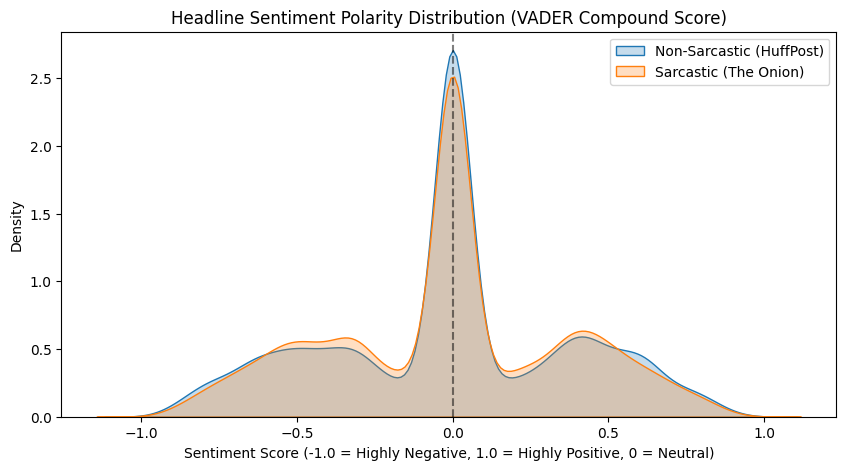


--- EXTREMELY POSITIVE SARCASTIC HEADLINES (Score > 0.7) ---
- obesity-study lab rat's life pretty sweet
- supreme court rules in favor of most buck-wild pride parade nation's ever seen
- friend takes liberty of ordering $40 worth of appetizers for entire table

--- EXTREMELY NEGATIVE SARCASTIC HEADLINES (Score < -0.7) ---
- area man's back aching after bad night's sleep, 58 continuous years of horrible posture
- trump solemnly lays wreath at site where he would have died during vietnam war if he weren't rich
- pope francis on vatican abuse scandal: 'just tell me whose feet to wash'


In [ ]:
# Download the VADER lexicon 
nltk.download('vader_lexicon')

# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Calculate the "Compound" score: 
# Ranges from -1 (Extremely Negative) to +1 (Extremely Positive). 0 is Neutral.
print("Calculating sentiment scores...")
df_clean['sentiment_score'] = df_clean['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Separate into the two classes
sentiment_real = df_clean[df_clean['is_sarcastic'] == 0]['sentiment_score']
sentiment_sarcastic = df_clean[df_clean['is_sarcastic'] == 1]['sentiment_score']

# ==========================================
# 1. VIEW SUMMARY STATISTICS
# ==========================================
print("\n--- Sentiment Score Summary ---")
print("Non-Sarcastic (HuffPost):")
print(sentiment_real.describe())
print("\nSarcastic (The Onion):")
print(sentiment_sarcastic.describe())

# ==========================================
# 2. PLOT THE SENTIMENT DISTRIBUTION
# ==========================================
plt.figure(figsize=(10, 5))
sns.kdeplot(sentiment_real, label='Non-Sarcastic (HuffPost)', fill=True, color='#1f77b4')
sns.kdeplot(sentiment_sarcastic, label='Sarcastic (The Onion)', fill=True, color='#ff7f0e')

plt.title('Headline Sentiment Polarity Distribution (VADER Compound Score)')
plt.xlabel('Sentiment Score (-1.0 = Highly Negative, 1.0 = Highly Positive, 0 = Neutral)')
plt.ylabel('Density')
plt.axvline(0, color='black', linestyle='--', alpha=0.5) # Mark the neutral baseline
plt.legend()
plt.show()

# ==========================================
# 3. EXAMINE THE EXTREMES (The Mismatches)
# ==========================================
print("\n--- EXTREMELY POSITIVE SARCASTIC HEADLINES (Score > 0.7) ---")
for headline in df_clean[(df_clean['is_sarcastic'] == 1) & (df_clean['sentiment_score'] > 0.7)]['headline'].sample(min(3, len(df_clean))):
    print(f"- {headline}")

print("\n--- EXTREMELY NEGATIVE SARCASTIC HEADLINES (Score < -0.7) ---")
for headline in df_clean[(df_clean['is_sarcastic'] == 1) & (df_clean['sentiment_score'] < -0.7)]['headline'].sample(min(3, len(df_clean))):
    print(f"- {headline}")